# Standard-methods results explorer

Analyse the counterfactuals produced by the standard-methods baseline stage.

- **Part 1 - Selection**: pick a dataset, view the initial samples, then choose one CF method and one sample.
- **Part 2 - Sample analysis**: inspect the chosen sample and the counterfactual(s) the selected method generated for it, plotted over the dataset background, plus how those CF predictions compare to the target.
- **Part 3 - Method metrics**: compare every CF method on sparsity, proximity, validity and more.

Widget/plot conventions mirror `dataset_priorities_explorer.ipynb`: continuous features use histograms, categorical features use category bars, and the target is treated as a continuous axis.

## Part 1 - Selection

Select a results dataset and load it. The initial samples used for the run are shown below.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ipywidgets as widgets
from IPython.display import display, clear_output

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'explainit').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp.standard_methods.predicted_dataset_setup import load_predicted_dataset

RESULTS_ROOT = (PROJECT_ROOT / 'explainit' / 'experiments' / 'continuous_minlp'
                / 'standard_methods' / 'results')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

STATE = {}

def current():
    if not STATE:
        raise RuntimeError('Select a dataset and click Load first.')
    return STATE

def scolor(i):
    return plt.get_cmap('tab10')(i % 10)

def available_result_datasets():
    if not RESULTS_ROOT.is_dir():
        return []
    return sorted([p.name for p in RESULTS_ROOT.iterdir() if (p / 'samples.csv').exists()])

def logical_value(vec, name):
    if name in STATE['numerical_index']:
        return float(vec[STATE['numerical_index'][name]])
    g = STATE['categorical_groups'][name]
    sub = [vec[i] for i in g['indices']]
    return int(np.argmax(sub))

def cat_label(name, code):
    code = int(code)
    cats = STATE['categorical_groups'][name].get('categories')
    if cats and 0 <= code < len(cats):
        return str(cats[code])
    return str(code)

def build_state(dataset_key):
    rdir = RESULTS_ROOT / dataset_key
    samples_df = pd.read_csv(rdir / 'samples.csv')
    cfs_df = pd.read_csv(rdir / 'counterfactuals.csv')
    summary_df = pd.read_csv(rdir / 'metrics_summary.csv')
    run_config = json.loads((rdir / 'run_config.json').read_text())
    feature_names = list(run_config['feature_names'])
    numerical_features = list(run_config['numerical_features'])
    categorical_groups = dict(run_config['categorical_groups'])
    epsilon = float(run_config['epsilon'])
    target_col = 'prediction'

    data = load_predicted_dataset(dataset_key)
    X_train = np.asarray(getattr(data['X_train'], 'values', data['X_train']), dtype=float)
    y_train = np.asarray(data['y_train'], dtype=float).reshape(-1)
    numerical_index = {n: feature_names.index(n) for n in numerical_features}

    STATE.clear()
    STATE.update(dict(dataset_key=dataset_key, samples_df=samples_df, cfs_df=cfs_df,
                      summary_df=summary_df, run_config=run_config, feature_names=feature_names,
                      numerical_features=numerical_features, categorical_groups=categorical_groups,
                      numerical_index=numerical_index, epsilon=epsilon, target_col=target_col,
                      X_train=X_train, y_train=y_train))

    logical = list(numerical_features) + list(categorical_groups.keys())
    default_kinds = {n: 'continuous' for n in numerical_features}
    for n in categorical_groups:
        default_kinds[n] = 'categorical'
    default_kinds[target_col] = 'continuous'
    STATE['display_feature_names'] = logical + [target_col]
    STATE['default_kinds'] = default_kinds

    rows = []
    for r in range(len(X_train)):
        vec = X_train[r]
        row = {n: logical_value(vec, n) for n in logical}
        row[target_col] = float(y_train[r])
        rows.append(row)
    STATE['disp_df'] = pd.DataFrame(rows)
    STATE['methods'] = sorted(cfs_df['method'].unique())
    STATE['sample_ids'] = list(samples_df['sample_id'])
    return STATE

_ds = available_result_datasets()
dataset_dd = widgets.Dropdown(options=_ds, value=(_ds[0] if _ds else None), description='Dataset:')
load_btn = widgets.Button(description='Load results', button_style='primary')
load_out = widgets.Output()

def _on_load(_=None):
    with load_out:
        clear_output(wait=True)
        if not dataset_dd.value:
            print('No result datasets found. Run runner.py first.')
            return
        build_state(dataset_dd.value)
        dk = STATE['dataset_key']; nm = len(STATE['samples_df']); ms = STATE['methods']
        print(f'Loaded dataset={dk} | samples={nm} | methods={ms}')
        print('Initial samples:')
        display(STATE['samples_df'].round(3))

display(widgets.HBox([dataset_dd, load_btn]))
display(load_out)
load_btn.on_click(_on_load)
if _ds:
    _on_load()

2026-07-05 13:50:06,278 - DEBUG - tensorflow - Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-07-05 13:50:06,653 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-05 13:50:06,653 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-05 13:50:06,654 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-05 13:50:06,654 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-05 13:50:07,373 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-07-05 13:50:07,374 - DEBUG - matplotlib.pyplot - Loaded backend inline version unknown.


Output()

Choose **one CF method** and **one sample** to analyse, then click *Use selection*. Part 2 analyses the counterfactual(s) this method generated for that sample.

In [2]:
st = current()
method_dd = widgets.Dropdown(options=st['methods'], description='Method:')
sample_dd = widgets.Dropdown(options=st['sample_ids'], description='Sample:')
use_btn = widgets.Button(description='Use selection', button_style='primary')
sel_out = widgets.Output()

def _on_use(_=None):
    with sel_out:
        clear_output(wait=True)
        STATE['sel_sample'] = int(sample_dd.value)
        STATE['sel_method'] = str(method_dd.value)
        sid = STATE['sel_sample']; mth = STATE['sel_method']
        sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == mth)]
        real = sub[sub['cf_prediction'].notna()]
        n_cf = len(real); n_valid = int(real['validity'].sum()) if n_cf else 0
        print(f'Selected method={mth}, sample_id={sid}')
        print(f'  {n_cf} counterfactual(s) generated for this sample ({n_valid} valid).')
        print('Now run the Part 2 cells below.')

display(widgets.HBox([method_dd, sample_dd, use_btn]))
display(sel_out)
use_btn.on_click(_on_use)
_on_use()

Output()

## Part 2 - Sample analysis

Analyse the selected sample and the counterfactual(s) the **selected method** generated for it. The table lists the original sample followed by each counterfactual (`cf_index`). Below, those CFs are plotted over the dataset background, and finally their predictions are compared to the target.

In [3]:
st = current()
sid = STATE.get('sel_sample'); mth = STATE.get('sel_method')
if sid is None:
    print('Run the Part 1 selection cell first.')
else:
    fn = st['feature_names']
    srow = st['samples_df'][st['samples_df']['sample_id'] == sid].iloc[0]
    rows = []
    base = {f: srow[f] for f in fn}
    base.update({'cf_index': 'ORIG', 'prediction': srow['original_prediction'],
                 'target': srow['target'], 'validity': '', 'abs_pred_error': 0.0,
                 'l1': 0.0, 'l2': 0.0, 'n_changed': 0})
    rows.append(base)
    sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == mth)]
    sub = sub.sort_values('cf_index')
    for _, r in sub.iterrows():
        d = {f: r['cf__' + f] for f in fn}
        d.update({'cf_index': r['cf_index'], 'prediction': r['cf_prediction'],
                  'target': r['target'], 'validity': r['validity'],
                  'abs_pred_error': r['abs_pred_error'], 'l1': r['l1'], 'l2': r['l2'],
                  'n_changed': r['n_changed']})
        rows.append(d)
    cols = ['cf_index', 'prediction', 'target', 'validity', 'abs_pred_error', 'l1', 'l2', 'n_changed'] + fn
    tbl = pd.DataFrame(rows)[cols]
    n_real = int(sub['cf_prediction'].notna().sum())
    print(f'Sample {sid} - method: {mth} ({n_real} counterfactual(s))')
    display(tbl.round(3))

Sample 60 - method: bayesian_optimization (5 counterfactual(s))


,cf_index,prediction,target,validity,abs_pred_error,l1,l2,n_changed,age,sex=0,sex=1,bmi,bp,s1,s2,s3,s4,s5,s6
0,ORIG,0.414,0.114,,0.000,0.000,0.000,0,-0.543,1.0,0.0,0.608,-0.142,1.738,1.951,-0.354,1.484,0.666,0.024
1,0,0.147,0.114,True,0.033,13.962,5.527,9,1.242,1.0,0.0,3.008,-1.898,2.983,-1.748,-0.063,1.847,-0.809,0.971
2,1,0.080,0.114,True,0.034,15.331,6.001,9,0.947,1.0,0.0,0.367,-2.166,3.016,-1.733,-1.909,-0.260,-2.309,-0.315
3,2,0.145,0.114,True,0.031,16.240,6.399,9,-0.436,1.0,0.0,2.833,-2.081,-0.260,-1.784,-0.057,-1.015,-2.061,0.737
4,3,0.143,0.114,True,0.029,17.071,6.623,9,1.187,1.0,0.0,3.152,-2.149,2.913,-2.374,0.521,1.112,1.912,-2.772
5,4,0.162,0.114,True,0.048,17.625,6.970,9,0.638,1.0,0.0,2.385,-1.503,-2.145,-1.819,2.202,0.923,-1.789,-0.056


### 1D distribution

Pick a feature (or the target). Continuous features show a histogram; categorical features show category bars. The sample value and the CF value(s) are overlaid. Enable *all methods* to compare every method's CF.

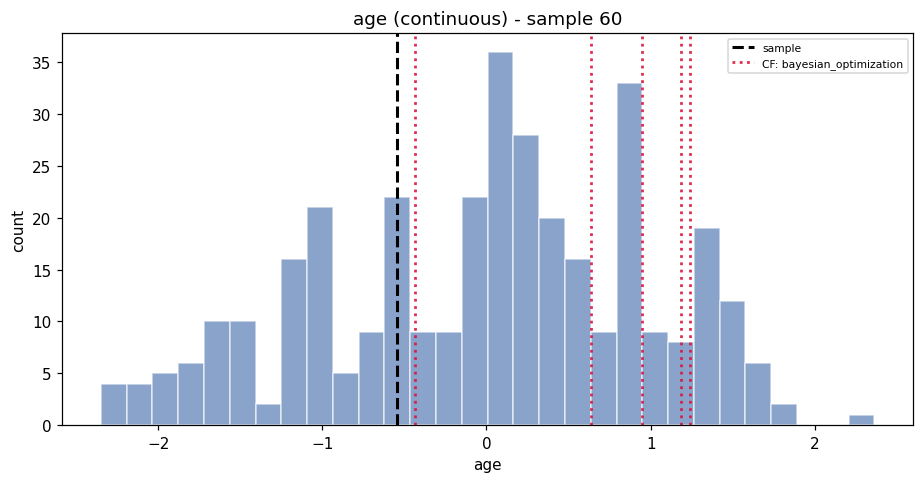

In [4]:
st = current()

def _sample_vec(sid):
    srow = st['samples_df'][st['samples_df']['sample_id'] == sid].iloc[0]
    return np.array([srow[f] for f in st['feature_names']], dtype=float), srow

def _cf_vecs(sid, method):
    sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == method)]
    sub = sub.sort_values('cf_index')
    out = []
    for _, r in sub.iterrows():
        vec = np.array([r['cf__' + f] for f in st['feature_names']], dtype=float)
        if np.any(pd.isna(vec)):
            continue
        out.append((vec, r))
    return out

def _feat_axis_value(feature, vec, rec, is_sample):
    if feature == st['target_col']:
        return float(rec['original_prediction'] if is_sample else rec['cf_prediction'])
    return logical_value(vec, feature)

def plot_1d(feature, kind, bins, logy, show_all):
    sid = STATE['sel_sample']; mth = STATE['sel_method']
    disp = st['disp_df']; tcol = st['target_col']
    svec, srow = _sample_vec(sid)
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    cat_to_x = {}
    if kind == 'continuous':
        vals = pd.to_numeric(disp[feature], errors='coerce').dropna().values
        ax.hist(vals, bins=bins, color='#4C72B0', alpha=0.65, edgecolor='white')
    else:
        counts = disp[feature].value_counts().sort_index()
        cat_to_x = {c: i for i, c in enumerate(counts.index)}
        xpos = np.arange(len(counts))
        ax.bar(xpos, counts.values, color='#55A868', alpha=0.85)
        ax.set_xticks(xpos)
        ax.set_xticklabels([cat_label(feature, c) for c in counts.index])
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel(feature); ax.set_ylabel('count')
    ymax = ax.get_ylim()[1]
    methods_to_plot = st['methods'] if show_all else [mth]
    sx = _feat_axis_value(feature, svec, srow, True)
    if kind == 'continuous':
        ax.axvline(sx, color='black', ls='--', lw=2, label='sample')
        for i, m in enumerate(methods_to_plot):
            col = scolor(i) if show_all else 'crimson'
            for j, (cvec, r) in enumerate(_cf_vecs(sid, m)):
                cx = _feat_axis_value(feature, cvec, r, False)
                ax.axvline(cx, color=col, ls=':', lw=1.8, alpha=0.9,
                           label=(f'CF: {m}' if j == 0 else None))
        if feature == tcol:
            tgt = float(srow['target']); eps = st['epsilon']
            ax.axvspan(tgt - eps, tgt + eps, color='green', alpha=0.12, label='target band')
            ax.axvline(tgt, color='green', lw=1.5, label='target')
    else:
        scode = int(sx)
        if scode in cat_to_x:
            ax.scatter([cat_to_x[scode]], [ymax * 0.96], color='black', marker='v', s=100, zorder=5, label='sample')
        for i, m in enumerate(methods_to_plot):
            col = scolor(i) if show_all else 'crimson'
            for j, (cvec, r) in enumerate(_cf_vecs(sid, m)):
                ccode = int(logical_value(cvec, feature))
                if ccode in cat_to_x:
                    ax.scatter([cat_to_x[ccode]], [ymax * (0.90 - 0.03 * i - 0.02 * j)],
                               color=col, marker='o', s=70, zorder=5,
                               label=(f'CF: {m}' if j == 0 else None))
    ax.legend(fontsize=7)
    ax.set_title(f'{feature} ({kind}) - sample {sid}')
    plt.tight_layout(); plt.show()

_feats = st['display_feature_names']
feat_dd = widgets.Dropdown(options=_feats, value=_feats[0], description='Feature:')
kind_dd = widgets.Dropdown(options=['continuous', 'categorical'],
                           value=st['default_kinds'][_feats[0]], description='Kind:')
bins_sl = widgets.IntSlider(value=30, min=5, max=80, step=5, description='Bins:')
logy_cb = widgets.Checkbox(value=False, description='log y')
all_cb = widgets.Checkbox(value=False, description='all methods')
plot_btn = widgets.Button(description='Plot', button_style='primary')
feat_dd.observe(lambda ch: setattr(kind_dd, 'value', st['default_kinds'][feat_dd.value]), names='value')

def _redraw_1d(make_plot=False):
    clear_output(wait=True)
    display(widgets.HBox([feat_dd, kind_dd]))
    display(widgets.HBox([bins_sl, logy_cb, all_cb, plot_btn]))
    if make_plot:
        plot_1d(feat_dd.value, kind_dd.value, bins_sl.value, logy_cb.value, all_cb.value)

plot_btn.on_click(lambda _=None: _redraw_1d(make_plot=True))
_redraw_1d(make_plot=False)

### 2D distribution

Plot two features against each other with the dataset in the background. Two continuous features use a 2D histogram; if either axis is categorical the dataset is shown as a jittered scatter with labelled category ticks. The sample (black X) is connected to each CF; when the target is on an axis its valid band is shaded green.

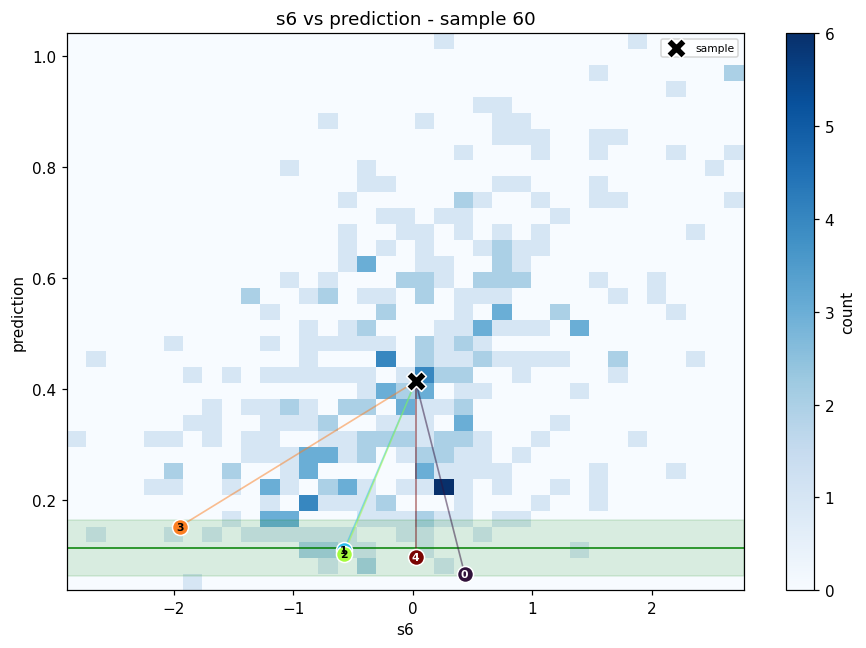

In [ ]:
st = current()

def _cf_idx(r):
    try:
        return int(r['cf_index'])
    except Exception:
        return None

def _build_cf_color_map(sid, methods_to_plot, cmap_name='turbo'):
    # Continuous rainbow-like mapping for potentially many CFs.
    keys = []
    for m in methods_to_plot:
        for _, r in _cf_vecs(sid, m):
            idx = _cf_idx(r)
            if idx is not None:
                keys.append((m, idx))
    keys = sorted(set(keys), key=lambda x: (x[1], x[0]))
    cmap = plt.get_cmap(cmap_name)
    if len(keys) <= 1:
        return {k: cmap(0.5) for k in keys}
    return {k: cmap(i / (len(keys) - 1)) for i, k in enumerate(keys)}

def _text_color(col):
    r, g, b = col[:3]
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if lum > 0.55 else 'white'

def plot_2d(fx, kx, fy, ky, bins, logc, show_all):
    sid = STATE['sel_sample']; mth = STATE['sel_method']
    disp = st['disp_df']; tcol = st['target_col']
    svec, srow = _sample_vec(sid)
    bx = pd.to_numeric(disp[fx], errors='coerce').values
    by = pd.to_numeric(disp[fy], errors='coerce').values
    fig, ax = plt.subplots(figsize=(8.5, 6))
    if kx == 'continuous' and ky == 'continuous':
        m = ~np.isnan(bx) & ~np.isnan(by)
        h = ax.hist2d(bx[m], by[m], bins=bins, cmap='Blues', norm=LogNorm() if logc else None)
        fig.colorbar(h[3], ax=ax, label='count')
    else:
        rng = np.random.default_rng(0)
        jx = 0.06 if kx == 'categorical' else 0.0
        jy = 0.06 if ky == 'categorical' else 0.0
        ax.scatter(bx + rng.normal(0, jx, size=len(bx)), by + rng.normal(0, jy, size=len(by)),
                   s=10, c='#CCCCCC', label='dataset', zorder=1)
        if kx == 'categorical':
            codes = sorted({int(v) for v in bx if not np.isnan(v)})
            ax.set_xticks(codes); ax.set_xticklabels([cat_label(fx, c) for c in codes])
        if ky == 'categorical':
            codes = sorted({int(v) for v in by if not np.isnan(v)})
            ax.set_yticks(codes); ax.set_yticklabels([cat_label(fy, c) for c in codes])
    sxx = _feat_axis_value(fx, svec, srow, True); syy = _feat_axis_value(fy, svec, srow, True)
    ax.scatter([sxx], [syy], marker='X', s=170, c='black', edgecolors='white', zorder=6, label='sample')
    methods_to_plot = st['methods'] if show_all else [mth]
    cf_color_map = _build_cf_color_map(sid, methods_to_plot, cmap_name='turbo')
    for i, m in enumerate(methods_to_plot):
        for j, (cvec, r) in enumerate(_cf_vecs(sid, m)):
            cf_idx = _cf_idx(r)
            col = cf_color_map.get((m, cf_idx), plt.get_cmap('turbo')(0.0))
            cxx = _feat_axis_value(fx, cvec, r, False); cyy = _feat_axis_value(fy, cvec, r, False)
            ax.plot([sxx, cxx], [syy, cyy], color=col, alpha=0.5, lw=1.1, zorder=4)
            ax.scatter([cxx], [cyy], s=110, color=col, edgecolors='white', zorder=7)
            if cf_idx is not None:
                ax.text(cxx, cyy, str(cf_idx), ha='center', va='center',
                        fontsize=7, color=_text_color(col), fontweight='bold', zorder=8)
    eps = st['epsilon']; tgt = float(srow['target'])
    if fx == tcol:
        ax.axvspan(tgt - eps, tgt + eps, color='green', alpha=0.12); ax.axvline(tgt, color='green', lw=1)
    if fy == tcol:
        ax.axhspan(tgt - eps, tgt + eps, color='green', alpha=0.12); ax.axhline(tgt, color='green', lw=1)
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.legend(fontsize=7)
    ax.set_title(f'{fx} vs {fy} - sample {sid}')
    plt.tight_layout(); plt.show()

_feats2 = st['display_feature_names']
fx_dd = widgets.Dropdown(options=_feats2, value=_feats2[0], description='X:')
kx_dd = widgets.Dropdown(options=['continuous', 'categorical'], value=st['default_kinds'][_feats2[0]], description='X kind:')
fy_dd = widgets.Dropdown(options=_feats2, value=_feats2[-1], description='Y:')
ky_dd = widgets.Dropdown(options=['continuous', 'categorical'], value=st['default_kinds'][_feats2[-1]], description='Y kind:')
bins2_sl = widgets.IntSlider(value=35, min=5, max=80, step=5, description='Bins:')
logc_cb = widgets.Checkbox(value=False, description='log scale')
all2_cb = widgets.Checkbox(value=False, description='all methods')
plot2_btn = widgets.Button(description='Plot', button_style='primary')
fx_dd.observe(lambda ch: setattr(kx_dd, 'value', st['default_kinds'][fx_dd.value]), names='value')
fy_dd.observe(lambda ch: setattr(ky_dd, 'value', st['default_kinds'][fy_dd.value]), names='value')

def _redraw_2d(make_plot=False):
    clear_output(wait=True)
    display(widgets.HBox([fx_dd, kx_dd]))
    display(widgets.HBox([fy_dd, ky_dd]))
    display(widgets.HBox([bins2_sl, logc_cb, all2_cb, plot2_btn]))
    if make_plot:
        plot_2d(fx_dd.value, kx_dd.value, fy_dd.value, ky_dd.value, bins2_sl.value, logc_cb.value, all2_cb.value)

plot2_btn.on_click(lambda _=None: _redraw_2d(make_plot=True))
_redraw_2d(make_plot=False)

### CF predictions vs target

For the selected sample, each counterfactual of the **selected method** is shown against the desired target (green line) and its valid band (shaded), with the original prediction as a dashed reference. Bars are green when the CF is valid (within the band), grey otherwise.

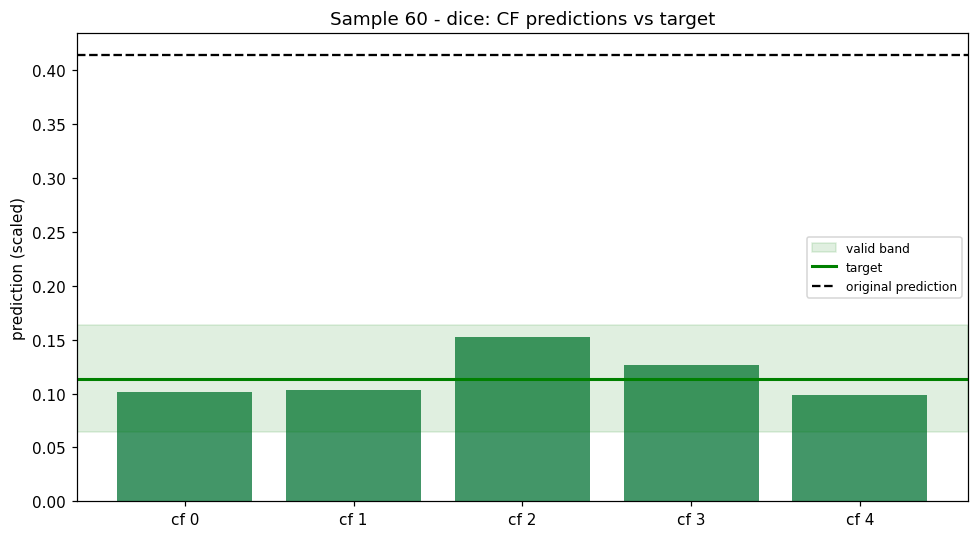

Distance of each CF prediction from target (sorted):


,cf_index,cf_prediction,target,abs_pred_error,l1,n_changed,validity
1,1,0.1036,0.114,0.0104,12.6789,8,True
3,3,0.1262,0.114,0.0122,13.7953,8,True
0,0,0.1013,0.114,0.0126,8.4684,9,True
4,4,0.0991,0.114,0.0148,14.2022,8,True
2,2,0.1525,0.114,0.0386,14.1750,8,True


In [22]:
st = current(); sid = STATE['sel_sample']; mth = STATE['sel_method']
srow = st['samples_df'][st['samples_df']['sample_id'] == sid].iloc[0]
tgt = float(srow['target']); op = float(srow['original_prediction']); eps = st['epsilon']
sub = st['cfs_df'][(st['cfs_df']['sample_id'] == sid) & (st['cfs_df']['method'] == mth)].copy()
sub = sub[sub['cf_prediction'].notna()].sort_values('cf_index')
if not len(sub):
    print(f'Method {mth} produced no counterfactual for sample {sid}.')
else:
    labels = [f'cf {int(i)}' for i in sub['cf_index']]
    preds = list(sub['cf_prediction'])
    colors = ['#2E8B57' if bool(v) else '#999999' for v in sub['validity']]
    fig, ax = plt.subplots(figsize=(9, 5))
    xpos = np.arange(len(labels))
    ax.bar(xpos, preds, color=colors, alpha=0.9)
    ax.axhspan(tgt - eps, tgt + eps, color='green', alpha=0.12, label='valid band')
    ax.axhline(tgt, color='green', lw=2, label='target')
    ax.axhline(op, color='black', ls='--', lw=1.5, label='original prediction')
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_ylabel('prediction (scaled)')
    ax.set_title(f'Sample {sid} - {mth}: CF predictions vs target')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
    dist = sub[['cf_index', 'cf_prediction', 'target', 'abs_pred_error', 'l1', 'n_changed', 'validity']].copy()
    dist = dist.sort_values('abs_pred_error')
    print('Distance of each CF prediction from target (sorted):')
    display(dist.round(4))

## Part 3 - Method metrics

Compare every CF method across the whole run. The first grid shows per-method aggregates from `metrics_summary.csv` (sample- and CF-level validity, number of valid CFs, proximity via L1/L2, sparsity via #changed / sparsity fraction, prediction error, runtime and iterations). The second grid shows per-CF distributions from `counterfactuals.csv`. Averages are computed over **valid** counterfactuals.

*Note:* the standard baseline methods do not compute a preference/priority score (that belongs to the MINLP branch), so it is not shown here.

In [ ]:
st = current(); summary = st['summary_df']
methods = list(summary['method'])
metrics = [('sample_validity_rate', 'sample validity rate'), ('cf_validity_rate', 'CF validity rate'),
           ('n_cfs_valid', '# valid CFs (total)'), ('avg_l1', 'avg L1 (proximity)'),
           ('avg_l2', 'avg L2 (proximity)'), ('avg_n_changed', 'avg #changed (sparsity)'),
           ('avg_sparsity_fraction', 'avg sparsity fraction'), ('avg_abs_pred_error', 'avg |pred - target|'),
           ('avg_time_seconds', 'avg time (s)'), ('avg_iterations', 'avg iterations')]
cols = 2; rows = int(np.ceil(len(metrics) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.0 * rows))
axes = np.atleast_1d(axes).ravel()
xpos = np.arange(len(methods))
for ax, (key, title) in zip(axes, metrics):
    ax.bar(xpos, summary[key].values, color=[scolor(i) for i in range(len(methods))], alpha=0.85)
    ax.set_xticks(xpos); ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
for j in range(len(metrics), len(axes)):
    axes[j].axis('off')
fig.suptitle('Per-method averages', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
st = current(); cfs = st['cfs_df']; methods = st['methods']
dist_metrics = [('l1', 'L1'), ('l2', 'L2'), ('sparsity_fraction', 'sparsity fraction'),
                ('n_changed', '#changed'), ('abs_pred_error', '|pred - target|'), ('time_seconds', 'time (s)')]
cols = 2; rows = int(np.ceil(len(dist_metrics) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.0 * rows))
axes = np.atleast_1d(axes).ravel()
for ax, (key, title) in zip(axes, dist_metrics):
    data = [cfs[cfs['method'] == m][key].dropna().values for m in methods]
    data = [d if len(d) else np.array([np.nan]) for d in data]
    ax.boxplot(data, labels=methods, showmeans=True)
    ax.set_title(title + ' (per CF)', fontsize=10)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45); lbl.set_ha('right'); lbl.set_fontsize(7)
for j in range(len(dist_metrics), len(axes)):
    axes[j].axis('off')
fig.suptitle('Per-CF distributions', fontsize=12)
plt.tight_layout(); plt.show()